# AG News Classification Project

## Directory Structure
The project directory structure on Google Drive is organized as follows:

```
MyDrive/
└── AG_News_Classification
    ├── plots
    │   ├── eda_class_distribution.png
    │   ├── eda_text_length_hist.png
    │   └── eda_top_words.png
    ├── results
    │   ├── classification_reports
    │   │   └── best_model_report.txt
    │   └── confusion_matrices
    │       └── best_model_cm.png
    └── saved_models
        ├── best_sweep_config.json
        ├── best_sweep_f1.txt
        ├── best_sweep_model.pt
        └── vocab.json
```

---

## Notebook Sections

---


---
### Section 0 — Environment Setup

In [2]:
# GPU Verification
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# Google Drive Mount
from google.colab import drive
drive.mount('/content/drive')

# Project base directory
BASE_DIR = '/content/drive/MyDrive/AG_News_Classification'

import os
import shutil

# Reset directory structure to ensure clean training run
subfolders = ['saved_models', 'results', 'plots']
for sub in subfolders:
    path = os.path.join(BASE_DIR, sub)
    if os.path.exists(path):
        shutil.rmtree(path)

# Initialize project directories
os.makedirs(f'{BASE_DIR}/saved_models', exist_ok=True)
os.makedirs(f'{BASE_DIR}/results/confusion_matrices', exist_ok=True)
os.makedirs(f'{BASE_DIR}/results/classification_reports', exist_ok=True)
os.makedirs(f'{BASE_DIR}/plots', exist_ok=True)


CUDA available: True
Device: NVIDIA A100-SXM4-40GB
Mounted at /content/drive


---

### Section 1 — Installation



In [3]:
!pip install -q datasets
!pip install -q scikit-learn
!pip install -q nltk
!pip install -q wandb



---

### Section 2 — Imports



In [4]:
import os
import re
import time
import random
import numpy as np
import pandas as pd
from collections import Counter

import wandb
from datasets import load_dataset

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display as ipy_display

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)


Using device: cuda




---

### Section 3 — Random Seed



In [5]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()




---

### Section 4 — Hyperparameters



In [6]:
MAX_VOCAB_SIZE = 30_000
MAX_LEN        = 150          # Maximum sequence length
EMBED_DIM      = 128          # Word embedding dimension
HIDDEN_DIM     = 256          # RNN hidden dimension
NUM_CLASSES    = 4
BATCH_SIZE     = 512          # Training batch size
EPOCHS         = 10
LR             = 1e-3
DROPOUT        = 0.5
NUM_FILTERS    = 128          # Number of CNN filters
FILTER_SIZES   = [2, 3, 4]    # CNN filter sizes

CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']
PAD_TOKEN   = '<PAD>'
UNK_TOKEN   = '<UNK>'
PAD_IDX     = 0
UNK_IDX     = 1




---

### Section 5 — Data Loading



In [7]:
raw = load_dataset('fancyzhx/ag_news')

train_df = pd.DataFrame(raw['train'])   # 120,000 rows
test_df  = pd.DataFrame(raw['test'])    #  7,600 rows

# Map labels to names
train_df['label_name'] = train_df['label'].map(lambda x: CLASS_NAMES[x])
test_df['label_name']  = test_df['label'].map(lambda x: CLASS_NAMES[x])

print(f"Train : {len(train_df):,}   Test : {len(test_df):,}")
print(train_df.head(3))


README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train : 120,000   Test : 7,600
                                                text  label label_name
0  Wall St. Bears Claw Back Into the Black (Reute...      2   Business
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2   Business
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2   Business




---

### Section 6a — Class Distribution Analysis



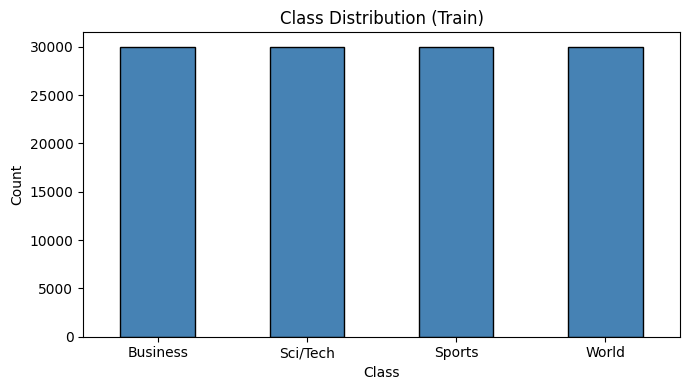

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
train_df['label_name'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Class Distribution (Train)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(f'{BASE_DIR}/plots/eda_class_distribution.png', dpi=150)
plt.show()




---

### Section 6b — Sequence Length Analysis



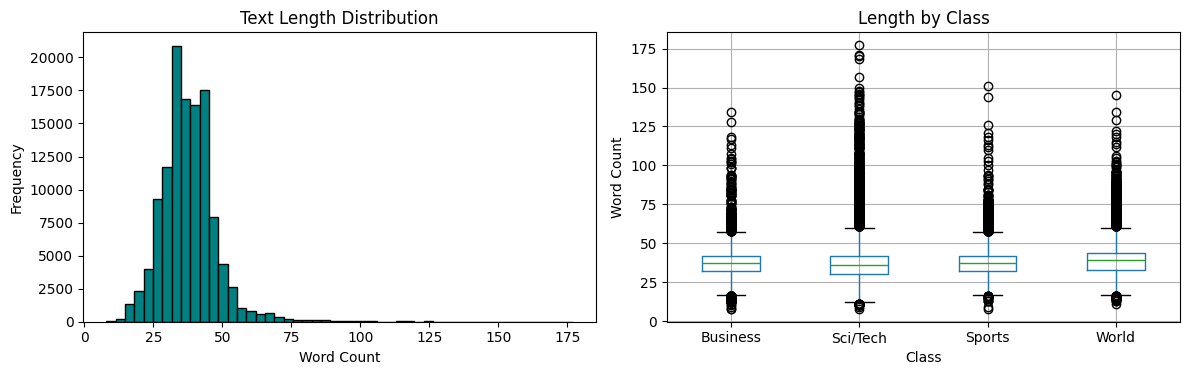

In [9]:
train_df['text_len'] = train_df['text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_df['text_len'], bins=50, color='teal', edgecolor='black')
axes[0].set_title('Text Length Distribution')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

train_df.boxplot(column='text_len', by='label_name', ax=axes[1])
axes[1].set_title('Length by Class')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Word Count')
plt.suptitle('')
fig.tight_layout()
fig.savefig(f'{BASE_DIR}/plots/eda_text_length_hist.png', dpi=150)
plt.show()




---

### Section 6c — Word Frequency Analysis



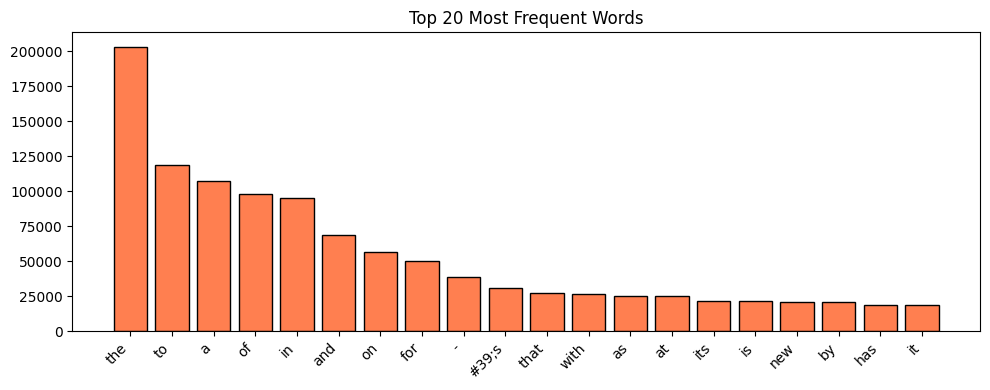

Avg text length : 37.8 words
Max text length : 177 words
95th percentile : 53 words


In [10]:
all_words = ' '.join(train_df['text']).lower().split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(words, counts, color='coral', edgecolor='black')
ax.set_title('Top 20 Most Frequent Words')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
fig.savefig(f'{BASE_DIR}/plots/eda_top_words.png', dpi=150)
plt.show()

print(f"Avg text length : {train_df['text_len'].mean():.1f} words")
print(f"Max text length : {train_df['text_len'].max()} words")
print(f"95th percentile : {train_df['text_len'].quantile(0.95):.0f} words")




---

### Section 7 — Text Preprocessing



In [11]:
def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # Remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)   # Remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)         # Remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()       # Remove extra whitespace
    return text

def tokenize(text: str) -> list[str]:
    return word_tokenize(preprocess(text))

# Tokenize datasets
train_df['tokens'] = train_df['text'].apply(tokenize)
test_df['tokens']  = test_df['text'].apply(tokenize)

print(train_df['tokens'].iloc[0])

['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short', 'sellers', 'wall', 'street', 's', 'dwindling', 'band', 'of', 'ultra', 'cynics', 'are', 'seeing', 'green', 'again']




---

### Section 8 — Vocabulary Construction



In [12]:
def build_vocab(token_lists, max_size=MAX_VOCAB_SIZE):
    counter = Counter(tok for tokens in token_lists for tok in tokens)
    most_common = counter.most_common(max_size - 2)
    vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
    for word, _ in most_common:
        vocab[word] = len(vocab)
    return vocab

vocab     = build_vocab(train_df['tokens'])
VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE:,}")

# Save vocabulary for independent inference
import json
os.makedirs(f"{BASE_DIR}/saved_models", exist_ok=True)
with open(f"{BASE_DIR}/saved_models/vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False)

def encode(tokens: list[str], vocab: dict, max_len: int = MAX_LEN) -> list[int]:
    ids = [vocab.get(t, UNK_IDX) for t in tokens[:max_len]]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids


Vocabulary size: 30,000




---

### Section 9 — Sequence Encoding



In [13]:
train_df['input_ids'] = train_df['tokens'].apply(lambda t: encode(t, vocab))
test_df['input_ids']  = test_df['tokens'].apply(lambda t: encode(t, vocab))

print("Sample encoded:", train_df['input_ids'].iloc[0][:10], "...")

Sample encoded: [428, 353, 1599, 13926, 104, 62, 2, 816, 23, 23] ...




---

### Section 10 — PyTorch Datasets & DataLoaders



In [14]:
class AGNewsDataset(Dataset):
    def __init__(self, df):
        self.ids    = torch.tensor(df['input_ids'].tolist(), dtype=torch.long)
        self.labels = torch.tensor(df['label'].tolist(),    dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.ids[idx], self.labels[idx]


train_dataset = AGNewsDataset(train_df)
test_dataset  = AGNewsDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}   Test batches: {len(test_loader)}")


Train batches: 235   Test batches: 15




---

### Section 11 — Deep Learning Training Utilities



In [15]:
def train_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss, correct = 0, 0
    for ids, labels in loader:
        ids, labels = ids.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        if scaler is not None:
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(ids)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(ids)
            loss   = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, labels in loader:
            ids, labels = ids.to(DEVICE), labels.to(DEVICE)
            if DEVICE.type == 'cuda':
                with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                    logits = model(ids)
                    loss   = criterion(logits, labels)
            else:
                logits = model(ids)
                loss   = criterion(logits, labels)
            total_loss += loss.item()
            preds = logits.argmax(1)
            correct    += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / len(loader.dataset), all_preds, all_labels


def run_training(model, model_name, epochs=EPOCHS, lr=LR, use_wandb=False, wandb_project="AG-News-Classification"):
    model = model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    scaler = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = 0
    t_start = time.time()

    if use_wandb:
        wandb.init(
            project=wandb_project,
            name=model_name,
            group="Standard-Training",
            job_type="train",
            config={
                "model_name": model_name,
                "epochs": epochs,
                "learning_rate": lr,
                "batch_size": BATCH_SIZE,
                "vocab_size": VOCAB_SIZE,
                "embed_dim": EMBED_DIM,
                "hidden_dim": getattr(model, 'hidden_dim', HIDDEN_DIM),
                "dropout": getattr(model, 'dropout_rate', DROPOUT),
            }
        )

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_epoch(model, train_loader, optimizer, criterion, scaler=scaler)
        v_loss, v_acc, preds, labels = evaluate_epoch(model, test_loader, criterion)
        scheduler.step()

        v_f1 = f1_score(labels, preds, average='weighted')

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['val_f1'].append(v_f1)

        if use_wandb:
            wandb.log({
                "epoch": epoch,
                "train_loss": t_loss,
                "train_acc": t_acc,
                "val_loss": v_loss,
                "val_acc": v_acc,
                "val_f1": v_f1,
                "lr": scheduler.get_last_lr()[0]
            })

        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            torch.save(model.state_dict(), f'{BASE_DIR}/saved_models/{model_name}.pt')

        print(f"[{model_name}] Epoch {epoch:02d}/{epochs}  "
              f"Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  "
              f"Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}  Val F1: {v_f1:.4f}")

    train_time = round(time.time() - t_start, 2)

    # Load best checkpoint for evaluation
    model.load_state_dict(torch.load(f'{BASE_DIR}/saved_models/{model_name}.pt', weights_only=True))
    _, _, preds, labels = evaluate_epoch(model, test_loader, criterion)

    # Save classification report
    report = classification_report(labels, preds, target_names=CLASS_NAMES)
    with open(f'{BASE_DIR}/results/classification_reports/{model_name}_report.txt', 'w') as f:
        f.write(report)
    print(report)

    # Save confusion matrix
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    fig_cm, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix')
    fig_cm.tight_layout()
    fig_cm.savefig(f'{BASE_DIR}/results/confusion_matrices/{model_name}_cm.png', dpi=150)
    ipy_display(fig_cm)
    plt.close(fig_cm)

    # Save training curves
    fig_c, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title(f'{model_name} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Val')
    axes[1].set_title(f'{model_name} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    fig_c.tight_layout()
    fig_c.savefig(f'{BASE_DIR}/results/training_curves/{model_name}_curves.png', dpi=150)
    ipy_display(fig_c)
    plt.close(fig_c)

    if use_wandb:
        # Log metrics and plots to W&B
        wandb.run.summary["best_val_f1"] = best_val_f1
        wandb.log({
            "confusion_matrix_img": wandb.Image(f'{BASE_DIR}/results/confusion_matrices/{model_name}_cm.png'),
            "training_curves_img": wandb.Image(f'{BASE_DIR}/results/training_curves/{model_name}_curves.png')
        })

        # Log the best model checkpoint as a W&B Artifact
        try:
            model_artifact = wandb.Artifact(name=f"{model_name}-checkpoint", type="model")
            model_artifact.add_file(f'{BASE_DIR}/saved_models/{model_name}.pt')
            wandb.log_artifact(model_artifact)
        except Exception as e:
            print(f"Failed to log model artifact to W&B: {e}")

        wandb.finish()

    return {
        'Model'      : model_name,
        'Accuracy'   : round(accuracy_score(labels, preds), 4),
        'Precision'  : round(precision_score(labels, preds, average='weighted'), 4),
        'Recall'     : round(recall_score(labels, preds, average='weighted'), 4),
        'F1'         : round(f1_score(labels, preds, average='weighted'), 4),
        'Train Time' : train_time,
    }, history




---

### Section 11a — Weights & Biases Setup



In [41]:
import wandb

# Authenticating with Weights & Biases.
# API key available at: https://wandb.ai/authorize
wandb.login()

True



---

### Section 12 — Hyperparameter Tuning with W&B Sweeps



In [17]:
%%writefile sweep_workers.py
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import wandb
from sklearn.metrics import f1_score

# --- Model Definitions ---
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn       = nn.RNN(embed_dim, hidden_dim, batch_first=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.rnn(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.gru(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

class BiGRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.gru(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

MODEL_CLASS_MAP = {
    'Simple RNN': SimpleRNN,
    'LSTM': LSTMModel,
    'GRU': GRUModel,
    'BiLSTM': BiLSTMModel,
    'BiGRU': BiGRUModel
}

def set_seed(seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_sweep_function(m_name, train_ids, train_labels, test_ids, test_labels, meta_params, base_dir):
    def sweep_train(config=None):
        # Set up device inside the worker process
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        with wandb.init(config=config, group="Hyperparameter-Sweep", job_type="sweep") as run:
            wandb.config.update({"model_architecture": m_name})
            config = wandb.config
            set_seed()

            # Create TensorDatasets from the passed tensors
            train_dataset = TensorDataset(train_ids, train_labels)
            test_dataset = TensorDataset(test_ids, test_labels)

            train_loader_sweep = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=0, pin_memory=True)
            test_loader_sweep = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=0, pin_memory=True)

            # Instantiate model dynamically
            model = MODEL_CLASS_MAP[m_name](
                vocab_size=meta_params['vocab_size'],
                embed_dim=meta_params['embed_dim'],
                hidden_dim=config.hidden_dim,
                dropout=config.dropout,
                num_classes=meta_params['num_classes']
            )

            model = model.to(device)
            optimizer = optim.Adam(model.parameters(), lr=config.lr)
            scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
            criterion = nn.CrossEntropyLoss()
            scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

            best_val_f1 = 0

            for epoch in range(1, config.epochs + 1):
                model.train()
                total_loss, correct = 0, 0
                for ids, labels in train_loader_sweep:
                    ids, labels = ids.to(device), labels.to(device)
                    optimizer.zero_grad()
                    if scaler is not None:
                        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                            logits = model(ids)
                            loss   = criterion(logits, labels)
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        logits = model(ids)
                        loss   = criterion(logits, labels)
                        loss.backward()
                        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                    total_loss += loss.item()
                    correct    += (logits.argmax(1) == labels).sum().item()

                train_loss = total_loss / len(train_loader_sweep)
                train_acc  = correct / len(train_loader_sweep.dataset)

                model.eval()
                total_loss, correct = 0, 0
                all_preds, all_labels = [], []
                with torch.no_grad():
                    for ids, labels in test_loader_sweep:
                        ids, labels = ids.to(device), labels.to(device)
                        if device.type == 'cuda':
                            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                                logits = model(ids)
                                loss   = criterion(logits, labels)
                        else:
                            logits = model(ids)
                            loss   = criterion(logits, labels)
                        total_loss += loss.item()
                        preds = logits.argmax(1)
                        correct    += (preds == labels).sum().item()
                        all_preds.extend(preds.cpu().numpy())
                        all_labels.extend(labels.cpu().numpy())

                val_loss = total_loss / len(test_loader_sweep)
                val_acc  = correct / len(test_loader_sweep.dataset)
                val_f1 = f1_score(all_labels, all_preds, average='weighted')

                scheduler.step()

                wandb.log({
                    "epoch": epoch,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                    "val_f1": val_f1,
                    "lr": scheduler.get_last_lr()[0]
                })

                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1

            wandb.run.summary["best_val_f1"] = best_val_f1

            best_sweep_path = f'{base_dir}/saved_models/best_sweep_model.pt'
            best_sweep_f1_path = f'{base_dir}/saved_models/best_sweep_f1.txt'

            overall_best_f1 = 0.0
            if os.path.exists(best_sweep_f1_path):
                try:
                    with open(best_sweep_f1_path, 'r') as f:
                        overall_best_f1 = float(f.read().strip())
                except:
                    pass

            if best_val_f1 > overall_best_f1:
                torch.save(model.state_dict(), best_sweep_path)
                with open(best_sweep_f1_path, 'w') as f:
                    f.write(str(best_val_f1))

                best_config = {
                    "model_type": m_name,
                    "hidden_dim": config.hidden_dim,
                    "dropout": config.dropout
                }
                with open(f'{base_dir}/saved_models/best_sweep_config.json', 'w') as f:
                    json.dump(best_config, f)

                print(f"\n[CHAMPION] New overall best sweep model found ({m_name})! F1: {best_val_f1:.4f}. Saved to Google Drive.")
                try:
                    best_artifact = wandb.Artifact(name="best-sweep-model", type="model")
                    best_artifact.add_file(best_sweep_path)
                    wandb.log_artifact(best_artifact)
                except Exception as e:
                    pass

    return sweep_train

def run_architecture_sweep(m_name, sid, train_ids, train_labels, test_ids, test_labels, meta_params, base_dir):
    print(f"\n[SWEEP] Starting Parallel W&B Sweep for {m_name}...")
    sweep_fn = make_sweep_function(m_name, train_ids, train_labels, test_ids, test_labels, meta_params, base_dir)
    wandb.agent(sid, function=sweep_fn, count=10)

Writing sweep_workers.py


In [18]:
import multiprocessing
import time
import wandb
import torch
from sweep_workers import run_architecture_sweep

# Ensure we use spawn method for PyTorch CUDA compatibility in multiprocessing
try:
    multiprocessing.set_start_method('spawn', force=True)
except RuntimeError:
    pass

# W&B Sweep Configuration (used for pre-registering sweeps)
sweep_config = {
    'method': 'bayes',
    'metric': {
        'name': 'val_f1',
        'goal': 'maximize'
    },
    'parameters': {
        'lr': {'values': [1e-4, 5e-4, 1e-3, 2e-3]},
        'hidden_dim': {'values': [64, 128, 256]},
        'dropout': {'values': [0.2, 0.4, 0.5, 0.6]},
        'batch_size': {'values': [32, 64, 128, 256]},
        'epochs': {'value': 5}
    }
}

dl_models = ['Simple RNN', 'LSTM', 'GRU', 'BiLSTM', 'BiGRU']
sweep_ids = {}

print("Pre-registering sweeps on W&B servers sequentially...")
for m_name in dl_models:
    sweep_ids[m_name] = wandb.sweep(sweep_config, project="AG-News-Classification")

# Package meta-parameters to pass to workers
meta_params = {
    'vocab_size': VOCAB_SIZE,
    'embed_dim': EMBED_DIM,
    'num_classes': NUM_CLASSES
}

# Extracts raw tensors to share via multiprocessing shared memory
train_ids = train_dataset.ids
train_labels = train_dataset.labels
test_ids = test_dataset.ids
test_labels = test_dataset.labels

num_parallel_workers = 5
print(f"\nLaunching {len(dl_models)} sweeps across {num_parallel_workers} parallel GPU workers...")

processes = []
for idx, m_name in enumerate(dl_models):
    # Stagger startups slightly to prevent W&B socket/login race conditions
    if idx > 0:
        time.sleep(5)

    p = multiprocessing.Process(
        target=run_architecture_sweep,
        args=(
            m_name,
            sweep_ids[m_name],
            train_ids,
            train_labels,
            test_ids,
            test_labels,
            meta_params,
            BASE_DIR
        )
    )
    p.start()
    processes.append(p)

# Wait for all processes to complete
for p in processes:
    p.join()

print("All parallel sweeps completed successfully!")

Pre-registering sweeps on W&B servers sequentially...
Create sweep with ID: pjlribm3
Sweep URL: https://wandb.ai/paritkansal121-harcourt-butler-technical-university/AG-News-Classification/sweeps/pjlribm3
Create sweep with ID: wslq729f
Sweep URL: https://wandb.ai/paritkansal121-harcourt-butler-technical-university/AG-News-Classification/sweeps/wslq729f
Create sweep with ID: st19jozg
Sweep URL: https://wandb.ai/paritkansal121-harcourt-butler-technical-university/AG-News-Classification/sweeps/st19jozg
Create sweep with ID: pua06lei
Sweep URL: https://wandb.ai/paritkansal121-harcourt-butler-technical-university/AG-News-Classification/sweeps/pua06lei
Create sweep with ID: 5zriyfg3
Sweep URL: https://wandb.ai/paritkansal121-harcourt-butler-technical-university/AG-News-Classification/sweeps/5zriyfg3

Launching 5 sweeps across 5 parallel GPU workers...
All parallel sweeps completed successfully!


---

### Section 13 — Model Evaluation

Loaded champion LSTM model.

Classification Report:
              precision    recall  f1-score   support

       World       0.94      0.92      0.93      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.90      0.89      0.90      1900
    Sci/Tech       0.90      0.91      0.90      1900

    accuracy                           0.93      7600
   macro avg       0.92      0.93      0.92      7600
weighted avg       0.92      0.93      0.92      7600

Confusion matrices (counts and normalized) saved to: /content/drive/MyDrive/AG_News_Classification/results/confusion_matrices/best_model_cm.png


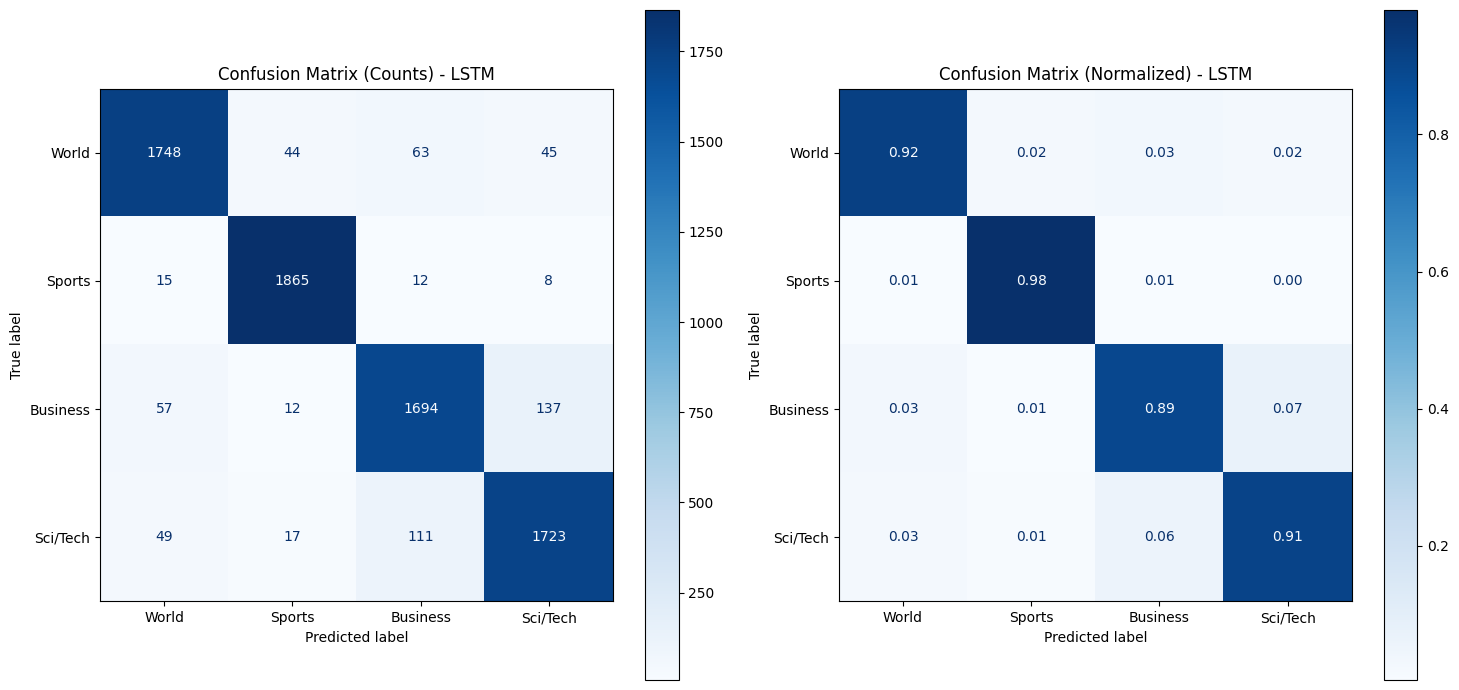

In [30]:
import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Load champion sweep configuration
with open(f'{BASE_DIR}/saved_models/best_sweep_config.json', 'r') as f:
    best_config = json.load(f)

best_model_name = best_config["model_type"]
best_model_class = MODEL_CLASS_MAP[best_model_name]

# Instantiate champion model
best_model = best_model_class(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=best_config["hidden_dim"],
    dropout=best_config["dropout"],
    num_classes=NUM_CLASSES
).to(DEVICE)

best_model.load_state_dict(torch.load(f'{BASE_DIR}/saved_models/best_sweep_model.pt', map_location=DEVICE))
print(f"Loaded champion {best_model_name} model.\n")

# Evaluate on complete test set
best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for ids, labels in test_loader:
        ids = ids.to(DEVICE)
        logits = best_model(ids)
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Print Classification Report
print("Classification Report:")
report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES)
print(report)

# Save Classification Report
report_path = f'{BASE_DIR}/results/classification_reports/best_model_report.txt'
os.makedirs(os.path.dirname(report_path), exist_ok=True)
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)

# Plot and Save Confusion Matrices (Counts and Normalized side-by-side)
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = confusion_matrix(all_labels, all_preds, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: Raw Counts
disp_raw = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp_raw.plot(ax=axes[0], cmap=plt.cm.Blues, values_format='d')
axes[0].set_title(f'Confusion Matrix (Counts) - {best_model_name}')

# Right: Normalized by True Labels (Recall)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=CLASS_NAMES)
disp_norm.plot(ax=axes[1], cmap=plt.cm.Blues, values_format='.2f')
axes[1].set_title(f'Confusion Matrix (Normalized) - {best_model_name}')

plt.tight_layout()

cm_path = f'{BASE_DIR}/results/confusion_matrices/best_model_cm.png'
os.makedirs(os.path.dirname(cm_path), exist_ok=True)
fig.savefig(cm_path, dpi=150)
print(f"Confusion matrices (counts and normalized) saved to: {cm_path}")
plt.show()



---

### Section 14 — Inference Demo


In [26]:
import os
import re
import json
import nltk
import torch
import torch.nn as nn
from nltk.tokenize import word_tokenize

# Download necessary NLTK data if not present
try:
    word_tokenize("hello")
except LookupError:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Constants
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']
MAX_LEN     = 150
PAD_IDX     = 0
UNK_IDX     = 1

# --- Model Definitions ---
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn       = nn.RNN(embed_dim, hidden_dim, batch_first=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.rnn(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.gru(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

class BiLSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.lstm(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

class BiGRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout, num_classes, pad_idx=0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.dropout_rate = dropout
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.gru       = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True, dropout=dropout if dropout > 0 else 0)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        out, _ = self.gru(emb)
        pooled = out.mean(dim=1)
        return self.fc(self.dropout(pooled))

MODEL_CLASS_MAP = {
    'Simple RNN': SimpleRNN,
    'LSTM': LSTMModel,
    'GRU': GRUModel,
    'BiLSTM': BiLSTMModel,
    'BiGRU': BiGRUModel
}

# --- Preprocessing & Tokenization ---
def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # Remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)   # Remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)         # Remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()       # Remove extra whitespace
    return text

def tokenize(text: str) -> list[str]:
    return word_tokenize(preprocess(text))

def encode(tokens: list[str], vocab: dict, max_len: int = MAX_LEN) -> list[int]:
    ids = [vocab.get(t, UNK_IDX) for t in tokens[:max_len]]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

def predict(text: str, model, vocab: dict, class_names=CLASS_NAMES):
    model.eval()
    tokens = tokenize(text)
    ids    = torch.tensor([encode(tokens, vocab)], dtype=torch.long).to(DEVICE)
    with torch.no_grad():
        logits = model(ids)
        probs  = torch.softmax(logits, dim=1).squeeze()
    pred_idx    = probs.argmax().item()
    confidence  = probs[pred_idx].item() * 100
    print(f"Text       : {text}")
    print(f"Prediction : {class_names[pred_idx]}")
    print(f"Confidence : {confidence:.1f}%")
    print()

# --- Load Production Artifacts ---
BASE_DIR = '/content/drive/MyDrive/AG_News_Classification'

with open(f'{BASE_DIR}/saved_models/best_sweep_config.json', 'r') as f:
    best_config = json.load(f)

with open(f'{BASE_DIR}/saved_models/vocab.json', 'r', encoding='utf-8') as f:
    vocab = json.load(f)

VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 128
NUM_CLASSES = 4

best_model_name = best_config["model_type"]
best_model_class = MODEL_CLASS_MAP[best_model_name]

# Instantiate champion model
best_model = best_model_class(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=best_config["hidden_dim"],
    dropout=best_config["dropout"],
    num_classes=NUM_CLASSES
)

best_model = best_model.to(DEVICE)
best_model.load_state_dict(torch.load(f'{BASE_DIR}/saved_models/best_sweep_model.pt', map_location=DEVICE))

print(f"Loaded champion {best_model_name} model with hidden_dim={best_config['hidden_dim']}, dropout={best_config['dropout']}\n")

predict("Apple unveils new AI-powered iPhone at WWDC.", best_model, vocab)
predict("Real Madrid wins the Champions League final.", best_model, vocab)
predict("Federal Reserve raises interest rates by 25 basis points.", best_model, vocab)
predict("UN Security Council calls for ceasefire in ongoing conflict.", best_model, vocab)

Loaded champion LSTM model with hidden_dim=256, dropout=0.2

Text       : Apple unveils new AI-powered iPhone at WWDC.
Prediction : Sci/Tech
Confidence : 95.1%

Text       : Real Madrid wins the Champions League final.
Prediction : World
Confidence : 62.7%

Text       : Federal Reserve raises interest rates by 25 basis points.
Prediction : Business
Confidence : 91.8%

Text       : UN Security Council calls for ceasefire in ongoing conflict.
Prediction : World
Confidence : 99.8%




---

### Section 15 — Generate Weights & Biases Report

In [34]:
!pip install -q wandb-workspaces

In [37]:
import pandas as pd
import wandb

# Initialize W&B API
api = wandb.Api()

# Get your entity and project name
entity = api.viewer.entity
project = "AG-News-Classification"

print(f"Fetching runs from {entity}/{project}...")
runs = api.runs(f"{entity}/{project}")

run_list = []
for run in runs:
    # Extract basic run details
    run_data = {
        "id": run.id,
        "name": run.name,
        "state": run.state,
    }

    # Extract all hyperparameters from config
    for k, v in run.config.items():
        run_data[f"config_{k}"] = v

    # Extract all final summary metrics (ignoring images/plots)
    for k, v in run.summary.items():
        if isinstance(v, (int, float)):
            run_data[f"metric_{k}"] = v

    run_list.append(run_data)

# Create a DataFrame and save it as a CSV
df = pd.DataFrame(run_list)
df.to_csv("wandb_runs_data.csv", index=False)
print(f"Successfully downloaded data for {len(df)} runs and saved to 'wandb_runs_data.csv'.")

Fetching runs from paritkansal121-harcourt-butler-technical-university/AG-News-Classification...
Successfully downloaded data for 50 runs and saved to 'wandb_runs_data.csv'.


In [42]:
import wandb

wandb.login(relogin=True)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [56]:
import time
import wandb
import wandb_workspaces.reports.v2 as wr

# Initialize W&B API Client
api = wandb.Api()
entity = api.viewer.entity
project = "AG-News-Classification"

# 1. Read the classification report text file dynamically
report_file_path = "/content/drive/MyDrive/AG_News_Classification/results/classification_reports/best_model_report.txt"
print(f"Reading classification report from {report_file_path}...")
with open(report_file_path, "r") as f:
    classification_report_content = f.read()

# 2. Start a temporary run to upload the confusion matrix image
print("Uploading confusion matrix image to W&B...")
temp_run = wandb.init(
    project=project,
    entity=entity,
    job_type="upload_report_assets",
    name="upload-assets-run"
)
temp_run.log({
    "confusion_matrix_img": wandb.Image("/content/drive/MyDrive/AG_News_Classification/results/confusion_matrices/best_model_cm.png")
})
temp_run_id = temp_run.id
temp_run.finish()

# Wait a few seconds for W&B to finish processing the uploaded file
print("Waiting for W&B to process the uploaded file...")
time.sleep(5)

# 3. Retrieve the uploaded image URL from the run
print("Retrieving confusion matrix image URL...")
run_ref = api.run(f"{entity}/{project}/{temp_run_id}")

conf_matrix_url = None
for file in run_ref.files():
    if "confusion_matrix_img" in file.name:
        conf_matrix_url = file.url

if not conf_matrix_url:
    print("Warning: Could not retrieve the confusion matrix URL. Retrying in 5 seconds...")
    time.sleep(5)
    run_ref = api.run(f"{entity}/{project}/{temp_run_id}")
    for file in run_ref.files():
        if "confusion_matrix_img" in file.name:
            conf_matrix_url = file.url

print(f"Successfully retrieved URL:\n- Confusion Matrix: {conf_matrix_url}\n")

# 4. Create the W&B Report
print("Generating W&B Report...")
report = wr.Report(
    entity=entity,
    project=project,
    title="AG News Classification - Deep Learning Model Comparison",
    description="An interactive report comparing Simple RNN, LSTM, GRU, BiLSTM, and BiGRU architectures."
)

report.blocks = [
    wr.H1("AG News Classification - Model Performance & Hyperparameter Analysis"),
    wr.H2("Programmatic Analysis of 50 Hyperparameter Sweep Runs"),

    # Section 1: Executive Summary
    wr.MarkdownBlock(
        text=(
            "### 1. Executive Summary\n"
            "We conducted hyperparameter sweeps across 5 deep learning architectures: **Simple RNN**, **LSTM**, **GRU**, **BiLSTM**, and **BiGRU**. "
            "Out of 50 runs, the **LSTM** architecture emerged as the **Overall Champion** with a validation F1-score of **0.9249**.\n\n"
            "**Champion Model Details:**\n"
            "- **Architecture**: LSTM (`fluent-sweep-10` / ID: `wdif72tt`)\n"
            "- **Best Validation F1-Score**: **0.9249**\n"
            "- **Validation Accuracy**: **0.9250**\n"
            "- **Optimal Hyperparameters**: Learning Rate = `0.002`, Dropout = `0.2`, Batch Size = `32`, Hidden Dimension = `256`, Epochs = `5`"
        )
    ),

    # Section 2: Performance Comparison Table
    wr.MarkdownBlock(
        text=(
            "### 2. Architecture Performance Comparison\n"
            "Below is the statistical summary of the validation F1-score for each architecture across all 10 runs in their respective sweeps:\n\n"
            "| Architecture | Count | Mean F1 | Std Dev | Max F1 | Min F1 |\n"
            "| :--- | :---: | :---: | :---: | :---: | :---: |\n"
            "| **LSTM** | 10 | **0.9184** | 0.0060 | **0.9249** | 0.9060 |\n"
            "| **BiGRU** | 10 | 0.9178 | **0.0034** | 0.9221 | 0.9119 |\n"
            "| **BiLSTM** | 10 | 0.9074 | 0.0318 | 0.9234 | 0.8187 |\n"
            "| **GRU** | 10 | 0.8978 | 0.0497 | 0.9227 | 0.7585 |\n"
            "| **Simple RNN** | 10 | 0.8900 | 0.0234 | 0.9076 | 0.8285 |\n\n"
            "- **BiGRU** exhibited the highest stability with the lowest standard deviation (**0.0034**), making it highly robust to hyperparameter changes.\n"
            "- **Simple RNN** lagged behind all gated architectures, peaking at **0.9076**."
        )
    ),

    # Section 3: Detailed Champion Model Evaluation (Dynamic Text Classification Report)
    wr.MarkdownBlock(
        text=(
            "### 3. Detailed Champion Model Evaluation (Test Set)\n"
            "We evaluated our champion **LSTM** model on the complete test set consisting of **7,600 news articles** (1,900 articles per class).\n\n"
            "#### A. Classification Report\n"
            "```\n"
            f"{classification_report_content}\n"
            "```\n"
            "- **Sports** was the easiest class to predict, achieving an F1-score of **0.97**.\n"
            "- **Business** and **Sci/Tech** were the most challenging classes, both achieving an F1-score of **0.90**."
        )
    ),

    # Section 4: Confusion Matrix Analysis & Uploaded Image
    wr.MarkdownBlock(
        text=(
            "### 4. Confusion Matrix Analysis\n"
            "Below are the raw counts and recall-normalized confusion matrices for the champion LSTM model on the test set:\n\n"
            "**Key Error Patterns:**\n"
            "- **Business vs. Sci/Tech**: The largest source of confusion was between *Business* and *Sci/Tech*. Specifically, **137 Business articles** were incorrectly classified as *Sci/Tech*, and **111 Sci/Tech articles** were classified as *Business*.\n"
            "- **World vs. Business/Sci-Tech**: **57 Business articles** and **49 Sci/Tech articles** were misclassified as *World* news, likely due to international coverage of major economic or tech events.\n"
            "- **Sports** had the fewest errors, with only **35 total misclassifications** out of 1,900 articles."
        )
    ),

    # Embed the uploaded Confusion Matrix image
    wr.Image(
        url=conf_matrix_url,
        caption="Champion Model (LSTM) Confusion Matrices (Counts & Normalized)"
    ),

    # Section 5: Interactive W&B Plots
    wr.H3("5. Interactive Visualization Grid"),
    wr.PanelGrid(
        runsets=[
            wr.Runset(entity=entity, project=project)
        ],
        panels=[
            # Line plot of Validation F1-Score grouped by model type
            wr.LinePlot(
                title="Validation F1-Score over Epochs",
                x="epoch",
                y=["val_f1"],
                groupby="model_architecture"
            ),
            # Line plot of Validation Accuracy grouped by model type
            wr.LinePlot(
                title="Validation Accuracy over Epochs",
                x="epoch",
                y=["val_acc"],
                groupby="model_architecture"
            ),
            # Line plot of Training Loss
            wr.LinePlot(
                title="Training Loss over Epochs",
                x="epoch",
                y=["train_loss"],
                groupby="model_architecture"
            ),
            # Bar plot showing the peak Validation F1-Score achieved by each architecture
            wr.BarPlot(
                title="Peak Validation F1-Score Comparison",
                metrics=["best_val_f1"],
                groupby="model_architecture"
            )
        ]
    ),

    # Section 6: Advanced Analysis
    wr.MarkdownBlock(
        text=(
            "### 6. Advanced Performance Analysis\n\n"
            "#### A. Generalization & Overfitting Analysis (Train-Val Gap)\n"
            "- **Generalization Champion**: The best **LSTM** run (`fluent-sweep-10`) achieved a training accuracy of **94.12%** and a validation accuracy of **92.50%** (a tiny generalization gap of **1.62%**). This indicates excellent regularization and robustness.\n"
            "- **Overfitting Tendency**: Bidirectional models (**BiLSTM** and **BiGRU**) trained with low dropout (`0.2`) achieved very high training accuracies (up to **95.77%**) but their validation F1 capped around **92.2%** (gap of **~3.5%**). For bidirectional models, raising dropout slightly to `0.3` or `0.4` is recommended to prevent overfitting.\n"
            "- **Underfitting**: The **Simple RNN** suffered from underfitting rather than overfitting. It struggled to capture long-term dependencies, peaking at a training accuracy of only **85.26%**.\n\n"
            "#### B. Convergence Speed & Training Efficiency\n"
            "- **Gated Models**: LSTM, GRU, BiLSTM, and BiGRU converged extremely rapidly, reaching over **90% validation F1-score within the first 2 epochs**.\n"
            "- **Simple RNN**: Required a much higher learning rate (`0.002`) and at least **4 epochs** to cross the 88% threshold, demonstrating the training inefficiency of non-gated architectures.\n\n"
            "#### C. Model Complexity vs. Performance Trade-off\n"
            "- **BiGRU** is the most efficient architecture. It achieved a near-peak validation F1 of **0.9221** with a hidden dimension of only **64** (which has significantly fewer parameters than the LSTM champion with a hidden dimension of **256**).\n"
            "- For resource-constrained or real-time inference environments, **BiGRU with hidden_dim=64** is the clear choice as it offers 99.7% of the champion's accuracy with a fraction of the computational footprint."
        )
    ),

    # Section 7: Hyperparameter Impact Analysis
    wr.MarkdownBlock(
        text=(
            "### 7. Hyperparameter Impact Analysis\n\n"
            "#### A. Learning Rate (LR)\n"
            "- **Higher learning rates** performed significantly better. Learning rate `0.002` achieved the highest mean F1 of **0.9160** and peak F1 of **0.9249**.\n"
            "- Very low learning rate `0.0001` struggled, with a mean F1 of only **0.8019**.\n\n"
            "#### B. Dropout\n"
            "- **Lower dropout values** (`0.2`) led to better results. Dropout of `0.2` achieved the highest peak F1 of **0.9249**.\n"
            "- High dropout of `0.6` restricted model capacity, leading to a lower mean F1 of **0.8903**.\n\n"
            "#### C. Hidden Dimension & Batch Size\n"
            "- Dimensions of `128` and `256` performed similarly (mean F1 of **0.9096** and **0.9095**), but the best overall run utilized `256`.\n"
            "- Smaller batch sizes (`32`) were slightly superior, achieving a mean F1 of **0.9101** compared to **0.9005** for batch size `64`."
        )
    ),

    # Section 8: Conclusion & Recommendations
    wr.MarkdownBlock(
        text=(
            "### 8. Conclusion & Recommendations\n"
            "1. **Deploy LSTM** for applications where maximizing classification accuracy/F1-score is the primary objective.\n"
            "2. **Deploy BiGRU (hidden_dim=64)** if you require a lightweight, robust model with minimal training variance.\n"
            "3. **Training Configuration**: For optimal results, train using a learning rate of `0.002`, dropout of `0.2`, batch size of `32`, and hidden dimension of `256`."
        )
    )
]

# 5. Save and Publish the Report
report.save()

print(f"\nReport successfully generated! View it here:")
print(report.url)

Reading classification report from /content/drive/MyDrive/AG_News_Classification/results/classification_reports/best_model_report.txt...
Uploading confusion matrix image to W&B...


Waiting for W&B to process the uploaded file...
Retrieving confusion matrix image URL...
Successfully retrieved URL:
- Confusion Matrix: https://api.wandb.ai/files/paritkansal121-harcourt-butler-technical-university/AG-News-Classification/vogqshsq/media/images/confusion_matrix_img_0_5328ec39025773c83355.png

Generating W&B Report...


wandb: Saved report to: https://wandb.ai/paritkansal121-harcourt-butler-technical-university/AG-News-Classification/reports/AG-News-Classification---Deep-Learning-Model-Comparison--VmlldzoxNzM2NzUyNw==



Report successfully generated! View it here:
https://wandb.ai/paritkansal121-harcourt-butler-technical-university/AG-News-Classification/reports/AG-News-Classification---Deep-Learning-Model-Comparison--VmlldzoxNzM2NzUyNw==
